## Visualisierung mit dem Paket matplotlib
Das Plotten und Visualisieren von Funktionsverläufen und anderen Daten ist eine alltägliche Aufgabe in sehr vielen Disziplinen. Wenig verblüffend existieren dazu zahlreiche Python-Pakete mit unterschiedlichen Funktionsumfängen, Anbindungsmöglichkeiten, und Graden an Benutzerfreundlichkeit.

Wir behandeln in dieser Lerneinheit das Paket **[matplotlib](https://matplotlib.org)**, das einen guten Kompromiss all dieser Ziele bietet.

### Grundlagen
Wir verabreden zunächst, dass wir die (für uns relevanten) Module aus dem Paket immer folgendermaßen einbinden: 

<code>import matplotlib.pyplot as plt</code>

Plots sind, wenigstens in matplotlib, eine ziemlich "diskrete" Angelegenheit. Das bedeutet insbesondere, dass lediglich Datenpunkte dargestellt werden, und im Fall der <code>plot()</code>-Funktion nur durch Linien (Geradenstücke) verbunden werden. Ein Plot bspw. einer kontinuierlichen Funktion ist also nichts anderes als ein Polygonzug.

Die einfachstmögliche Nutzung der <code>plot()</code> Funktion ist die Übergabe einer einzelnen Liste oder eines einzelnen NumPy-ndarray. Diese Werte werden dann interpretiert als die Ordinaten ("y-Werte") zu den Abszissen ("x-Werte") 0,1,2,...

Weiter ist wichtig, dass wir einen Plot immer "inkrementell zusammenbauen", erst durch Aufruf der Funktion <code>show()</code> wird er auch angezeigt. Das folgende Beispiel verdeutlicht all dies, wobei die "magic commands" <code>%matplotlib ...</code> in manchen Jupyter-Installationen nötig sind, und in gängigen IDEs typischerweise nicht.


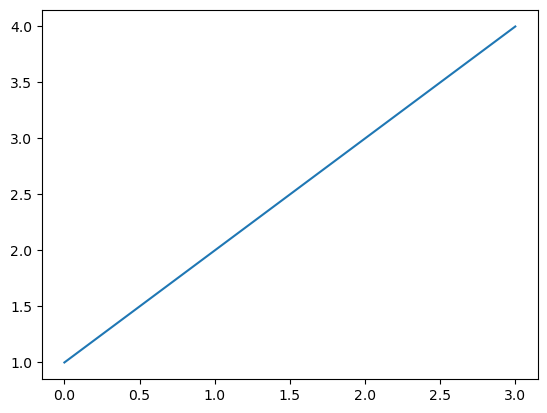

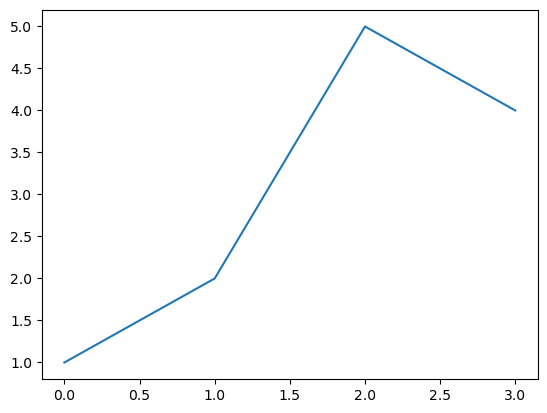

In [1]:
# das hier scheint in einigen Jupyter-Installationen nötig zu sein,
# und muss evtl. in anderen Entwicklungsumgebungen auskommentiert werden
#%matplotlib notebook
# für weniger "interaktive" Plots ist manchmal auch das hier
# ausreichend in einigen Jupyter-Installationen
#%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

# ein Plot aus einer Python-Liste
plt.plot([1, 2, 3, 4])
plt.show()

# noch ein Plot, diesmal aus einem ndarray
plt.plot(np.array([1, 2, 5, 4]))
plt.show()

### Plotten von Funktionen
Um Funktionen plotten zu können, müssen wir die Datenpunkte zunächst berechnen, damit matplotlib sie als Paare von Abszissen und Ordinaten interpretieren und dann durch einen Polygonzug visualisieren kann. Der <code>plot()</code> Befehl akzeptiert hierzu zwei Listen oder NumPy-ndarrays, die jeweils gleich viele Einträge enthalten müssen. Die Einträge des ersten Arguments sind die Abszissen, und die des zweiten Arguments die Ordinaten, wobei die Paarung über den gemeinsamen Index erfolgt.

Für die Erstellung des Abszissen-Arrays bietet sich im einfachsten Fall die NumPy-Funktion <code>linspace()</code> an, die in einem gegebenen Intervall Punkte äquidistant verteilt. Für die Erstellung der Ordinaten (Funktionsauswertungen) sollte, sofern möglich, eine vektorisierte Berechnung verwendet werden. Für die Funktionen der <code>math</code> Bibliothek müssen wir die Vektorisierung nicht zu Fuss implementieren, sondern können die entsprechenden Funktionen des NumPy-Pakets verwenden.

Die folgende Serie von Codeschnipseln verdeutlicht dies, und illustriert nochmals, dass Plots immer Polygonzüge sind:

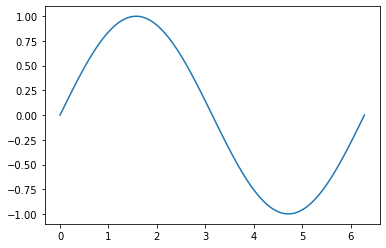

In [ ]:
#%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Abszissen: 100 äquidistante Punkte in [0,pi]
x = np.linspace(0, 2*np.pi, 100)
# Ordinaten: vektorisierte Auswertung der Sinusfunktion
y = np.sin(x)
# ... und der Plot
plt.plot(x,y)
plt.show()

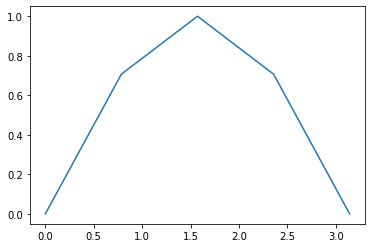

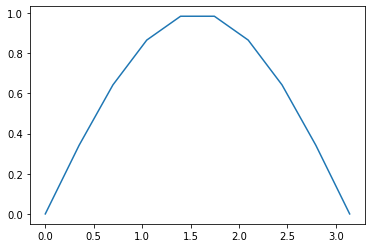

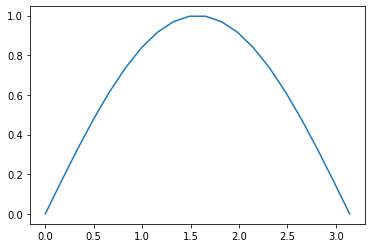

In [ ]:
#%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Verdeutlichung des Polygonzugs:
for points in [5,10,20]:
    x = np.linspace(0, np.pi, points)
    y = np.sin(x)
    plt.plot(x,y)
    plt.show()

Default von linspace:  50


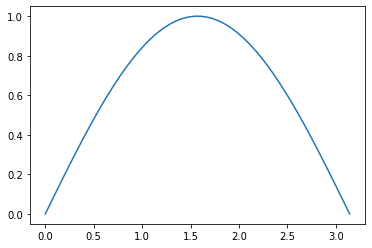

In [ ]:
#%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Wir können uns natürlich auch auf das Default-Argument
# von linspace() verlassen und hoffen, dass das Ergebnis
# "einigermaßen glatt" aussieht:
x = np.linspace(0, np.pi)
print("Default von linspace: ", x.size)
y = np.sin(x)
plt.plot(x,y)
plt.show()

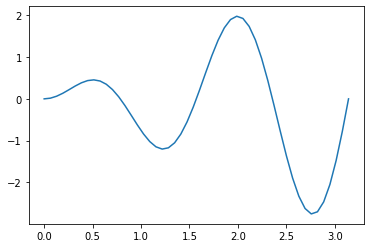

In [ ]:
#%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, np.pi)
# Hier wird gleich mehrfach vektorisiert gerechnet:
y = np.sin(4*x)*x
plt.plot(x,y)
plt.show()

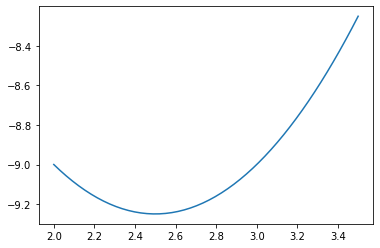

In [ ]:
#%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(2, 3.5)
# Auch anonyme Funktionen (lambda-Funktionen) werden vektorisiert,
# wenn sie auf ein NumPy-Array losgelassen werden.
# Damit sind lambda-Funktionen die benutzerfreundlichste Methode,
# wenn matplotlib als graphikfähiger Taschenrechner dient.
f = lambda x: x**2 - 5*x - 3
y = f(x)
plt.plot(x,y)
plt.show()
# Hier sehen wir auch, dass matplotlib versucht, 
# die Achsen sinnvoll zu beschriften

### Schönere Plots durch Beschriftungen und Legenden
Plots sollten grundsätzlich eine vernünftige Achsenbeschriftung und eine Legende enthalten. Hierfür existieren (unter anderem) die Funktionen <code>title()</code>, <code>legend()</code>, <code>ylabel()</code> sowie <code>xlabel()</code>.

Im Gegensatz dazu wird das Label selbst (der Text in der Legende) direkt als optionales Argument beim Aufruf von <code>plot()</code> übergeben. Hierbei ist das Label (und übrigens auch alle anderen Beschriftungen) eine ganz normale Zeichenkette, die wir bspw. mit <code>.format()</code> hübsch gestalten können. 

Die Legende selbst muss explizit angeschaltet werden durch Aufruf der Funktion <code>legend()</code>. Mit Hilfe des optionalen Arguments <code>loc</code> kann die Position variiert werden, zur Verfügung stehen <code>'best', 'upper right' , 'upper left', 'lower left', 'lower right', 'right', 'center left', 'center right', 'lower center', 'upper center', 'center'</code>.

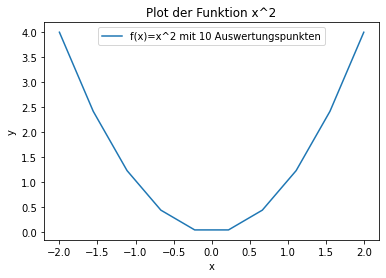

In [ ]:
#%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

num_points = 10
x = np.linspace(-2, 2,num_points)
y = x**2

# Das Label in der Legende ist ein optionales Argument:
my_label = "f(x)=x^2 mit {:d} Auswertungspunkten".format(num_points)
plt.plot(x,y, label=my_label)
# Annotationen/Beschriftungen kommen NACH dem plot()-Befehl,
# dann ist die Reihenfolge allerdings egal:
plt.xlabel("x")
plt.ylabel("y")
plt.title("Plot der Funktion x^2")
plt.legend()  # Default ist loc='best'
#plt.legend(loc='center')
plt.show()


### Anpassung des dargestellten Bereichs
Mit den Funktionen <code>xlim()</code> und <code>ylim()</code> kann der darzustellende Wertebereich festgelegt werden. Wenn wir ihn, wie bisher in den Beispielen, nicht angeben, so wird als maximaler y-Bereich das Maximum der darzustellenden Werte über dem gegebenen x-Bereich gewählt. 

Die Funktionen <code>xlim()</code> und <code>ylim()</code> akzeptieren als Argumente jeweils die zu berücksichtigenden Intervalle. Dies kann entweder durch zwei Werte erfolgen, wobei die Reihenfolge "links-rechts" bzw. "unten-oben" ist. Auch eine Angabe als ein Tupel-Argument anstelle zweier Argumente ist möglich.

Wichtig ist: Sobald wir eine dieser Funktionen verwenden, um Wertebereiche zu setzen ("um auf einen Ausschnitt zu zoomen"), so müssen wir immer auch die jeweils andere verwenden.

Wenn wir eine dieser Funktionen ohne Argumente aufrufen, so wird der aktuell verwendete Wertebereich zurückgegeben.

aktuelles x-Intervall: (-1100.0, 1100.0)
aktuelles y-Intervall: (-49999.999562378616, 1049999.999979161)


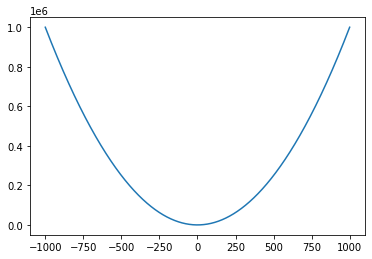

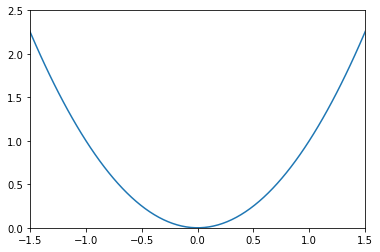

In [ ]:
#%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# ein absurd großer Bereich zur Auswertung
x = np.linspace(-1000, 1000, 48984)
y = x**2

# mit dem Wissen bisher:
plt.plot(x,y)
print("aktuelles x-Intervall:", plt.xlim())
print("aktuelles y-Intervall:", plt.ylim())
plt.show()  # wir sehen, das die Achsenskalierung schlau ist

# mit dem neuen Wissen:
plt.plot(x,y)
plt.xlim(-1.5,1.5)
plt.ylim(0,2.5)
plt.show()


### Visualisierung mehrerer Kurven in einer Graphik
Durch einen mehrmaligen Aufruf der <code>plot()</code> Funktion können mehrere Darstellungen gewissermaßen "übereinander gelegt" werden. 

Hierbei wird automatisch die Farbe angepasst, sowie die Zuordnung der Legende zu den Darstellungen übernommen. Außerdem bestimmt matplotlib den Wertebereich für die x- und y-Achsen automatisch aus dem Maximum der Wertebereiche der einzelnen Kurven. 

Die Achsenbeschriftungen und der Titel beziehen sich auf die gesamte resultierende Graphik.

Es existieren zwei Kurzformen: Einerseits kann natürlich die Funktion, die die Ordinaten generiert, Teil der Argumentliste des <code>plot()</code> Befehls sein, das sollte mit unserem bisherigen Kenntnisstand keine Überraschung sein: Unter der Haube entspricht dies der komponentenweisen Auswertung einer Funktion für alle Einträge einer Liste oder eines ndarrays. Andererseits können wir alles in einem <code>plot()</code> Befehl zusammenfassen, wenn wir eine gewisse Reihenfolge der Argumente einhalten.


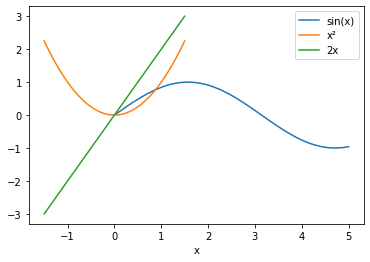

In [ ]:
#%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

x1 = np.linspace(0, 5)
y1 = np.sin(x1)
x2 = np.linspace(-1.5, 1.5)
y2 = x2**2 # ist das numpy-Potenzieren
plt.plot(x1, y1, label="sin(x)")
plt.plot(x2, y2, label="x²")
# erwartbare Kurzschreibweise des zweiten Arguments:
plt.plot(x2, 2*x2, label="2x")  
plt.xlabel("x")
plt.legend()
plt.show()

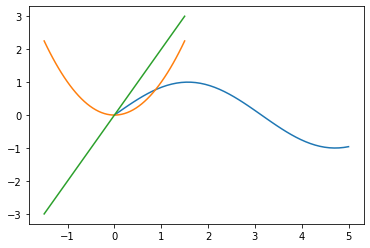

In [ ]:
#%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

x1 = np.linspace(0, 5)
y1 = np.sin(x1)
x2 = np.linspace(-1.5, 1.5)
y2 = x2**2

# Dasselbe wie im Beispiel eben, nur kompakter:
# Hierbei müssen die Label anders benannt werden.
# Weil das "kompliziert" ist, einigen wir uns darauf,
# pro "Kurve" einen Plot-Befehl zu verwenden.
plt.plot(x1, y1,
         x2, y2,
         x2, 2*x2
        )
plt.show()

### Anpassung der Farbe und des Plot-Stils
Für jeden einzelnen Plot können die Farbe, der Linienstil und der Marker separat festgelegt werden. Dies erfolgt kompakt durch die Angabe eines sogenannten **Formatierungsstring**, der als drittes Argument an den <code>plot()</code> Befehl übergeben wird. Der Formatierungsstring besteht aus drei Komponenten, und es wird empfohlen die Reihenfolge Marker, Linienstil und Farbe einzuhalten. Fehlt eine (Teil-) Angabe, wird auf Standardwerte zurückgegriffen.

Einige unterstützte Marker sind: <code>'.'</code> für Punkte, <code>'o'</code> für Kreise, <code>'v', '^', '&lt;','&gt;'</code> für Dreiecke, <code>'s'</code> für Quadrate, <code>'x'</code> für Kreuze, <code>'D', 'd'</code> für Diamanten, und <code>'|', '_'</code> für Striche.

An Linienstilen stehen <code>'-'</code> (durchgezogen), <code>'--'</code> (gestrichelt), <code>'-.'</code> (Punkt-Strich) und <code>':'</code> (gepunktet) zur Verfügung. 

Die Farbcodes lauten <code>'r','g','b','c','y','m','k','w'</code>, wobei <code>'k'</code> für schwarz steht, weil der Buchstabe <code>'b'</code> bereits für blau vergeben ist.

Eine vollständige Übersicht findet sich in der [Dokumentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) in der Rubrik "Notes".

Wichtig ist auch noch das Keyword-Argument <code>linewidth=</code> (abgekürzt <code>lw=</code>), mit dem die Linienstärke gesetzt wird. Das folgende Beispiel zeigt nur einige Möglichkeiten, es wird empfohlen, die unterschiedlichen Stile und Varianten selbst einmal auszuprobieren:


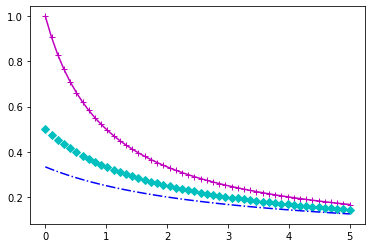

In [ ]:
#%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 5)
# Marker +, Linienstil -- und Farbe m (magenta)
plt.plot(x, 1/(x+1), '+-m')
# Marker D (diamond), keine Linie und Farbe c (cyan)
plt.plot(x, 1/(x+2), 'Dc')
# Kein Marker, Linienstil -. und Farbe b (blau)
plt.plot(x, 1/(x+3), '-.b')
plt.show()

### Weitere Anpassungsmöglichkeiten
Es existieren noch zahlreiche andere Möglichkeiten, einen Plot an die eigenen Vorstellungen anzupassen. Dies geschieht über Keyword-Argumente. Wir betrachten nur ein Beispiel, eine vollständige Übersicht findet sich in der [Dokumentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) in der Rubrik <code>\*\*kwargs</code>.

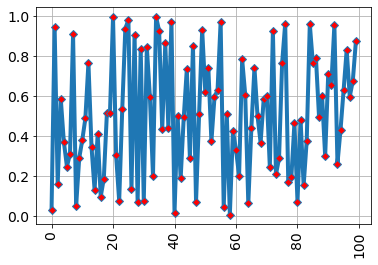

In [ ]:
#%matplotlib inline
import random 
import matplotlib.pyplot as plt

y = [random.random() for i in range(100)]  # zappelnde Daten

# Ein Beispiel:
plt.plot(y, linewidth=4, marker="D", markerfacecolor="r") # Default-Abszissen
# Manuelles Setzen von Farben, um den gesamten RGB-Farbraum auszuschöpfen:
#plt.plot(y, linewidth=4, marker="D", markerfacecolor=(1.0, 0.0, 0.0))  #rot

# Anzeige eines Hintergrundgitters
plt.grid()

# Anpassen der Beschriftung
plt.xticks(fontsize=14, rotation=90)
plt.yticks(fontsize=14)
plt.show()

### Speicherung von Plots in Dateien
Um einen Plot weiterzuverwenden, bspw. in einem $\LaTeX$-Dokument, müssen wir ihn speichern. Anstatt einen Screenshot zu nehmen, empfiehlt es sich, die dafür vorgesehene matplotlib-Funktion zu verwenden. Sie stellt sicher, dass die resultierende Graphikdatei skalierbar ist über verschiedene Auflösungen. 

Der zugehörige Befehl lautet <code>savefig()</code>, und kann neben oder anstelle des Befehls <code>show()</code> aufgerufen werden. Das einzige Pflichtargument ist der Dateiname:
    
    savefig(filename, dpi=None, facecolor='w', edgecolor='w',
        orientation='portrait', papertype=None, format=None,
        transparent=False, bbox_inches=None, pad_inches=0.1,
        frameon=None)
        


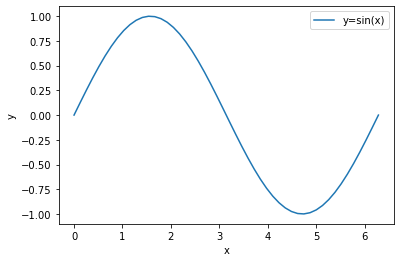

In [ ]:
#%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2*np.pi)
plt.plot(x, np.sin(x), label="y=sin(x)")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
# Die Dateiendung gibt den Dateityp vor:
plt.savefig("figure.png")
plt.savefig("figure.pdf")
plt.savefig("figure.svg")

## Mini-Aufgaben zur Überprüfung des Verständnis: Grundlagen von matplotlib

Plotten Sie die Funktionen $\sin(x)$, $\cos(x)$ und $\tan(x)$ auf dem Intervall $[-2\pi,2\pi]$ in einer Darstellung. Experimentieren Sie mit Beschriftungen, Labels und dem dargestellten Bereich, um ein möglichst aussagekräftiges Ergebnis zu erzielen.

Speichern Sie den Plot anschließend in eine PDF-Datei, öffnen Sie diese in einem PDF-Betrachter, und verifizieren Sie, dass die Grafikdatei bei Größenänderungen in Word etc. tatsächlich skaliert, und nicht "pixelig" wird.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ...

Der folgende Plot ist mit Matplotlib erstellt worden. Leider ist der zugehörige Programmcode verschwunden. Rekonstruieren Sie den Plot durch Ablesen der Funktionswerte und Angabe der korrekten Linienstile.

Hinweis: <code>np.interp()</code> kann hilfreich sein, wenn Sie keine Geradengleichungen ausrechnen wollen.

![bla.png](attachment:bla.png)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ...

## Weitere Anwendungsmöglichkeiten des Pakets matplotlib

Wir lernen noch einige weitere Möglichkeiten des Pakets kennen. Für einen umfassenderen Überblick über die Funktionsvielfalt verweisen wir auf die [matplotlib Gallerie](https://matplotlib.org/stable/gallery/index.html), hier konzentrieren wir uns auf
* Subplots: Kombination mehrerer Plots in einer Graphik,
* Manuelle Annotationen innerhalb eines Plots,
* Säulendiagramme,
* Histogramme,
* Scatterplots,
* Bildbearbeitung, und
* Interaktive Plots.


### Subplots: Kombination mehrerer Plots in einer Graphik
Häufig müssen mehrere Plots untereinander oder nebeneinander ausgegeben werden. Dies leistet der <code>subplot(n,m,p)</code> Befehl. Die Zahlen <code>n,m</code> geben hierbei die Anzahl der Plots pro "Dimension" an (n Zeilen und m Spalten), mit <code>p</code> kann der Plot ausgewählt werden. Außerdem lassen sich so Achsen teilen und viele andere Anpassungen mehr vornehmen.

Details: [Dokumentation von pyplot.subplot()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplot.html)

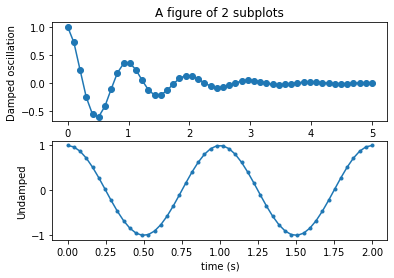

In [ ]:
#%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

x1 = np.linspace(0.0, 5.0)
x2 = np.linspace(0.0, 2.0)

y1 = np.cos(2 * np.pi * x1) * np.exp(-x1)
y2 = np.cos(2 * np.pi * x2)

# Anlegen eines 2x1 Plots, "Scharfschalten" des ersten Unterplots:
plt.subplot(2, 1, 1)
plt.title('A figure of 2 subplots')  # muss im ersten "Block" stehen
plt.plot(x1, y1, 'o-')
plt.ylabel('Damped oscillation')

# Scharfschalten des zweiten Unterplots:
plt.subplot(2, 1, 2)
plt.plot(x2, y2, '.-')
plt.xlabel('time (s)')
plt.ylabel('Undamped')

plt.show()

### Manuelle Annotationen innerhalb eines Plots
Manchmal ist es didaktisch sinnvoll, in einem Plot "herumzumalen", um besondere Aspekte gewissermaßen zu markieren und die Aufmerksamkeit dahin zu lenken. Dies kann mit der Funktion <code>annotate()</code> realisiert werden. Sie akzeptiert, in dieser Reihenfolge, die folgenden Argumente,
* Eine Zeichenkette mit dem Annotationstext
* Die Koordinaten, an der die Annotation erscheinen soll; das Koordinatensystem ist hierbei standardmäßig das, was der Achsenbeschriftung entspricht. Es empfiehlt sich also, den Plot zunächst ohne die Annotation auszugeben, um die Koordinaten des zu annotierenden Punkts ablesen zu können, es sei denn, wir kennen die Daten analytisch
* Sollen zusätzlich Pfeilchen gezeichnet werden, werden als nächstes die Koordinaten des eigentlichen Texts angegeben. Matplotlib zeichnet dann einen Pfeil zwischen den gegebenen Koordinaten.
* Eigenschaften des Pfeils in Form eines <code>dict</code>

Details: [Dokumentation von pyplot.annotate()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.annotate.html)

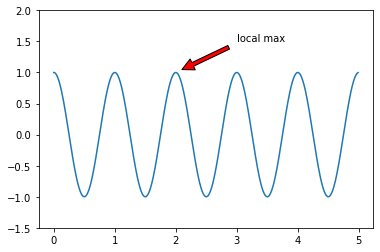

In [ ]:
#%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Wir plotten zunächst eine einfache Funktion:
x = np.arange(0.0, 5.0, 0.01)
y = np.cos(2*np.pi*x)
plt.plot(x, y)

# dict mit den gewünschten Eigenschaften des Pfeilchens
arrow_properties = {
    "facecolor": "red",
    "shrink": 0.1     # 0.1*Länge Abstand von Start- und Endpunkt ist hübscher
}

# hier wird annotiert
plt.annotate('local max', xy=(2, 1), xytext=(3, 1.5),
            arrowprops=arrow_properties)

plt.ylim(-1.5,2)
plt.show()

### Säulendiagramme

Säulendiagramme sind oft sinnvoll, realisiert durch die Funktion <code>bar()</code>. Sie erfordert, in dieser Reihenfolge, mindestens folgenden Argumente:
* <code>x</code>: darzustellende Abszissen, bspw. als Liste oder NumPy-ndarray
* <code>height</code>: darzustellende Ordinaten, identisch indiziert wie <code>x</code>

Details: [Dokumentation von pyplot.bar()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html)

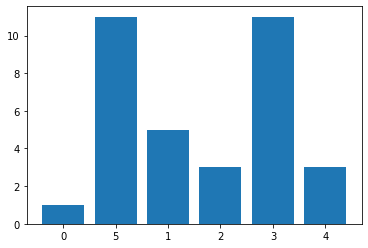

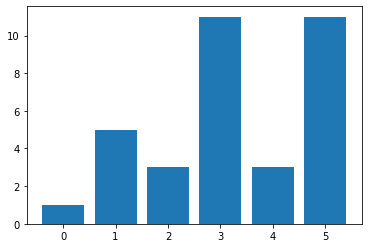

In [ ]:
#%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Wir zählen die Vorkommen der 10 Ziffern in einer Beispielzahl
zahl = "0.511112233333333334455555555512345"
counts = {}
for c in zahl:
    # Ausfiltern des Dezimalpunkts auf sehr ineffiziente Art
    if not c.isdigit():
        continue
        
    # Falls c noch nicht als Key in counts abgelegt ist,
    # initialisiere counts[c] als 0.
    if c not in counts:
        counts[c] = 0

    counts[c] += 1

plt.bar( list(counts.keys()), list(counts.values()) )
plt.show()


# so geht es sortiert mit einer dict comprehension:
counts_sorted = {i:counts[i] for i in sorted(counts.keys())}
plt.bar( list(counts_sorted.keys()), list(counts_sorted.values()) )
plt.show()



### Histogramme

Diese Art der graphischen Darstellung erlaubt das automatische "Einsortieren" in gegebene Wertebereiche. Man sollte bei der Nachbereitung einen Moment darüber nachdenken, warum dies **nicht** die Darstellung der Wahl im vorherigen Beispiel ist. 

Die entsprechende matplotlib-Funktion lautet <code>hist()</code>. Folgende Argumente sollte man kennen:
* <code>x</code>: Eingabewerte, bspw. als Liste oder NumPy-ndarray
* <code>bins (optional)</code>: Anzahl der "Eimer", in die die Daten einsortiert werden sollen: 
 * Wird eine Zahl übergeben, erfolgt die Einteilung in die angegebene Anzahl an "Eimern", wobei das von den Eingabewerten aufgespannte Intervall äquidistant unterteilt wird. Wird nichts angegeben, dann gilt der Defaultwert von 10 bins.
 * Wird eine **geordnete** Liste übergeben, definiert diese die (nicht notwendig äquidistante) Einteilung in bins. Bis auf das letzte sind die Intervalle halboffen.
* <code>rwidth (optional)</code>: Breite der Säulen, relativ zur Gesamtbreite
 
Wir demonstrieren dies im nächsten Codeschnipsel, indem wir experimentell herausfinden, wie "gleichverteilt" der Zufallszahlen-Generator von NumPy ist. Wie immer bei Zufallsexperimenten sollte man das mehrmals laufen lassen.

Details: [Dokumentation von pyplot.hist()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html)

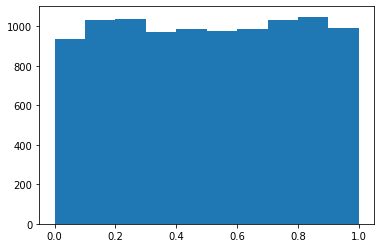

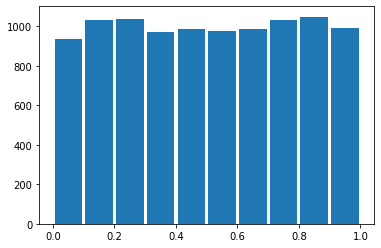

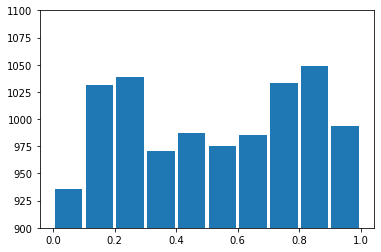

In [ ]:
#%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

n = 10000
bins = 10
x = np.random.random(n)
plt.hist(x,bins)
plt.show()

# wir sehen, dass wir wenig sehen, deshalb nochmal hübscher
plt.hist(x,bins,rwidth=0.9)
plt.show()

# und in noch hübscher durch Anpassung des y-Wertebereichs
plt.hist(x,bins,rwidth=0.9)
plt.ylim(900,1100)
plt.show()

### Punktwolken
Diese Visualisierung ist die vermutlich "primitivste" graphische Darstellung von Daten, insbesondere wenn (initial) kein funktionaler Zusammenhang zugrunde liegt oder bekannt ist. Die zu interpretierenden Daten im $\mathbb{R}^2$ oder $\mathbb{R}^3$ werden einfach als Punktwolke geplottet. 

Solche Punktwolken können in matplotlib mit der Funktion <code>scatter(x, y)</code> dargestellt werden. Hier sind die Argumente <code>x</code> und <code>y</code> Vektoren oder Listen oder allgemein identisch indizierbar: Ein Datum wird identifiziert als das Tupel <code>(x[i],y[i])</code>, oder entsprechend in 3D. 

Details: [Dokumentation von pyplot.scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)

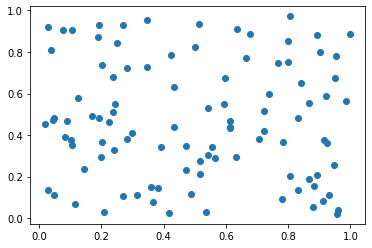

In [ ]:
#%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

num_points = 100
X = np.random.random(num_points)
Y = np.random.random(num_points)

plt.scatter(X,Y)
plt.show()


Als weiteres Beispiel betrachten wir die Suche nach den Punkten mit einem vorgegebenen euklidischen Abstand von einem gegebenen Punkt, und wollen wir das Ergebnis mit matplotlib visualisieren:

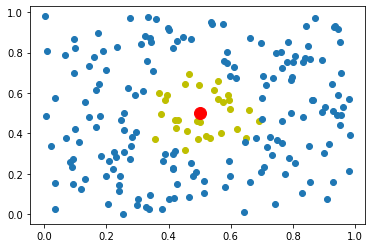

In [ ]:
#%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Anlegen m zufälliger Vektoren im R^2
# und speichern der Vektoren in einer Matrix
# X=[x0 x2 ... xm-1]
n = 2
m = 200
X = np.random.random((n,m))

# Mittelpunkt der Suche:
x_star = np.array([[0.5, 0.5]]).T

# Berechnen aller Abstände zum Vektor x_star:
distances = np.sqrt( np.sum((X - x_star)**2, axis=0) )

# Kleinste Abstände finden,
# vgl. https://numpy.org/doc/stable/reference/generated/numpy.argsort.html
I = np.argsort(distances)

# Plotten der k Punkte mit geringstem Abstand:
k = 30
plt.scatter(X[0,I[:k]], X[1,I[:k]], c="y")
plt.scatter(X[0,I[k+1:]], X[1,I[k+1:]])
plt.plot(x_star[0], x_star[1], "or", markersize=12)
plt.show()

### Bilddateien

Mit dem Unterpaket <code>image</code> stellt matplotlib Methoden zur Ein- und Ausgabe von Bildern dar. Ein Bild ist dabei im Wesentlichen als ein 2D Array bei Grauwertbildern oder Farbindex-Bildern, bzw. als ein 3D Array bei RGB oder RGBA Farbbildern gespeichert. Dies ermöglicht die Bildbearbeitung in Python, bspw. um Kantenerkennung, Weichzeichnung oder andere Filter zu implementieren. 

Wir laden zunächst eine Datei. Im zweiten Codeschnipsel "bearbeiten" wir das Bild rudimentär, um zu verdeutlichen, dass ein Bild tatsächlich nichts anderes ist als ein zweidimensionales Array. Das dritte Beispiel zeigt, wie wir Bildchen selbst erzeugen können.

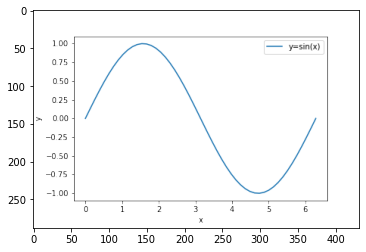

In [ ]:
#%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as img

image = img.imread('figure.png')
plt.imshow(image)
plt.show()

(288, 432, 4)


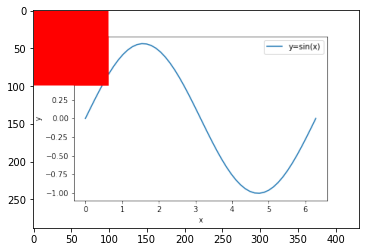

In [ ]:
#%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as img

image = img.imread('figure.png')

print(image.shape)
#print(image) # 3D array mit 4 Einträgen per Pixel: RGBA
image[1:100,1:100,:] = [1.0, 0.0, 0.0, 1.0] # "rumsauen" im Bild
plt.imshow(image)
plt.show()

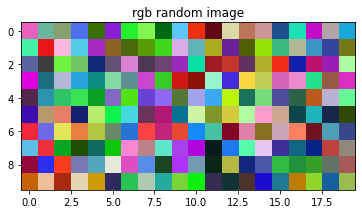

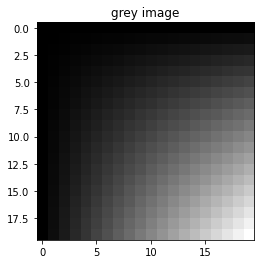

(20, 20)


In [ ]:
#%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as img

# Erzeugen eines 10x20 RBG Bildchens
img_rgb_black = np.random.random( (10,20,3) )
plt.imshow(img_rgb_black)
plt.title("rgb random image")
plt.show()

# Graustufen-Bildchen
v1 = np.linspace(0,1,20) # 1D array
v1_matrix = np.reshape(v1, (20,1) ) # jetzt Matrix mit einer Spalte
img_grey = v1_matrix.dot(v1_matrix.T) # dyadisches Produkt
plt.imshow(img_grey, cmap="gray")
plt.title("grey image")
plt.show()

print(np.shape(img_grey))

### Interaktive Plots
Mit matplotlib können interaktive Plots erzeugt werden, in der Tat ist dies oft der Default, wenn mit einer IDE oder aus der Konsole heraus gearbeitet wird. In Jupyter Notebook ist dies mit <code>%matplotlib notebook</code> möglich, wenn das Paket <code>ipymlp</code> installiert ist.

<IPython.core.display.Javascript object>


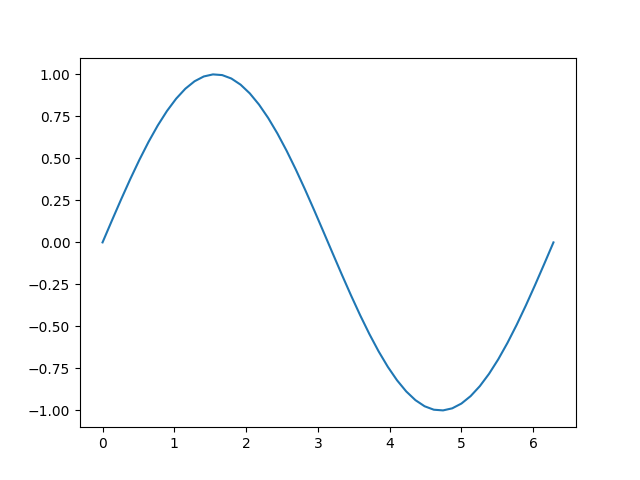

In [ ]:
%matplotlib notebook

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0,2*np.pi)
plt.plot (x, np.sin(x))
plt.show()

## Mini-Aufgaben zur Überprüfung des Verständnis: Fortgeschrittene Aspekte der matplotlib

### Säulendiagramme

Auf der Seite [statistica.de](https://de.statista.com/statistik/daten/studie/36151/umfrage/anzahl-der-internetnutzer-in-deutschland-nach-altersgruppen-seit-1997/) finden Sie eine Entwicklung der Internetnutzung aufgeteilt nach Altersgruppen, für die Jahren 1997 bis 2022. Übersetzen Sie die Daten für 2022 in ein Säulendiagramm (Balkendiagramm).


In [ ]:
import matplotlib.pyplot as plt

# Eingabedaten, in Millionen
# frei verwendbar gemäß statistica.de
data = {
    "14--19 Jahre" : 4.7,
    "20--29 Jahre" : 9.5,
    "30--39 Jahre" : 10.6,
    "40--49 Jahre" : 10,
    "50--59 Jahre" : 12.6,
    "60--69 Jahre" : 9.9,
    "70+ Jahre"    : 9.8
}

# ...

### Nebenrechnung

Übersetzen Sie die obigen Daten in Prozentangaben der Gesamtbevölkerung. Verwenden Sie dazu die Referenzgröße von 84.3 Millionen Staatsangehörigen Ende 2022. Vergessen Sie nicht, die Differenz zu 100% im zu erstellenden Dictionary als "offline" aufzunehmen.

In [ ]:
data = {
    "14--19 Jahre" : 4.7,
    "20--29 Jahre" : 9.5,
    "30--39 Jahre" : 10.6,
    "40--49 Jahre" : 10,
    "50--59 Jahre" : 12.6,
    "60--69 Jahre" : 9.9,
    "70+ Jahre"    : 9.8
}

# ...

### Darstellung als Tortendiagramm

Verwenden Sie die berechneten Prozentzahlen, um ein Tortendiagramm zu erstellen. Lesen Sie sich dazu in die Dokumentation von [plt.pie()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pie.html), bzw. finden Sie bei Bedarf ein geeignetes Tutorial im Netz.

Hinweis: Sie benötigen nur das erste Argument von <code>plt.pie()</code>, und eventuell das benannte Argument <code>labels</code>. Denken Sie genau darüber nach, welche Daten des Dictionaries zu welchem Argument gehören. 

In [ ]:
import matplotlib.pyplot as plt

data_percent = {
    "14--19 Jahre" : 5.58,
    "20--29 Jahre" : 11.27,
    "30--39 Jahre" : 12.57,
    "40--49 Jahre" : 11.86,
    "50--59 Jahre" : 14.95,
    "60--69 Jahre" : 11.74,
    "70+ Jahre"    : 11.63,
    "offline"      : 20.4
}

# ...


### Scatterplots in 3D 
Solche Plots werden leicht anders erzeugt, insbesondere müssen wir leicht tiefer in die Interna der matplotlib eintauchen. Verstehen Sie dazu das Tutorial unter [https://pythonprogramming.net/matplotlib-3d-scatterplot-tutorial/](https://pythonprogramming.net/matplotlib-3d-scatterplot-tutorial) oder ein beliebig anderes aus dem Netz, und programmieren Sie es nach.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ...